Hello, welcome to my notebook. I hope my binary classification model helps you out in your own projects.

Background:
In binary classification, a complex dataset has an added 'target' label with one of two options (thus binary). My learning algorithm will try to assign one of these labels to the dataset.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/playground-series-s4e1/sample_submission.csv
/kaggle/input/playground-series-s4e1/train.csv
/kaggle/input/playground-series-s4e1/test.csv


In [2]:
# Helper function that helps us draw nicely formatted confusion matrices
def draw_confusion_matrix(y, yhat, classes):
    '''
        Draws a confusion matrix for the given target and predictions
        Adapted from scikit-learn and discussion example.
    '''
    plt.cla()
    plt.clf()
    matrix = confusion_matrix(y, yhat)
    plt.imshow(matrix, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.colorbar()
    num_classes = len(classes)
    plt.xticks(np.arange(num_classes), classes, rotation=90)
    plt.yticks(np.arange(num_classes), classes)

    fmt = 'd'
    thresh = matrix.max() / 2.
    for i, j in itertools.product(range(matrix.shape[0]), range(matrix.shape[1])):
        plt.text(j, i, format(matrix[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if matrix[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

In [3]:
# importing needed packages
from imblearn.over_sampling import RandomOverSampler
import seaborn as sns
import matplotlib.pyplot as plt
from numpy import mean, std
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
import sklearn.metrics.cluster as smc
from sklearn.model_selection import KFold
import itertools
from matplotlib import pyplot

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [4]:
# loading data
train_data = pd.read_csv("/kaggle/input/playground-series-s4e1/train.csv")
test_data = pd.read_csv("/kaggle/input/playground-series-s4e1/test.csv")

# view the first five columns of training data
train_data.head()

train = train_data.copy()
test = test_data.copy()

In [5]:
# the training data shape/size
train_data.shape, test_data.shape

((165034, 14), (110023, 13))

In [6]:
# analyze the data statistics
train_data.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [7]:
# check the data types in case they're different
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB


As you can see, we should convert the object datatypes into ints or floats to match the rest of the data. We can do this with encoding.

In [8]:
encoder = LabelEncoder()
categorical_features = train_data.select_dtypes(include = 'object').columns
print("Categorical features: ", categorical_features)
for feature in categorical_features:
    train_data[feature] = encoder.fit_transform(train_data[feature])

Categorical features:  Index(['Surname', 'Geography', 'Gender'], dtype='object')


In [9]:
encoder = LabelEncoder()
for feature in categorical_features:
    train_data[feature] = encoder.fit_transform(train_data[feature])

In [10]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  int64  
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  int64  
 5   Gender           165034 non-null  int64  
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(9)
memory usage: 17.6 MB


In [11]:
train_data.isnull()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165029,False,False,False,False,False,False,False,False,False,False,False,False,False,False
165030,False,False,False,False,False,False,False,False,False,False,False,False,False,False
165031,False,False,False,False,False,False,False,False,False,False,False,False,False,False
165032,False,False,False,False,False,False,False,False,False,False,False,False,False,False


There are no null values, so no need to worry about those either. Let's drop all the duplicate values now!

In [12]:
train_data.drop_duplicates(inplace = True, keep = 'first')

Let's label the 'Exited' category as our target.

In [13]:
train_data['Target'] = (train_data['Exited']).astype(int)
del train_data['Exited']
train_data.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Target
0,0,15674932,1924,668,0,1,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,1925,627,0,1,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,1178,678,0,1,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,1299,581,0,1,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,467,716,2,1,33.0,5,0.00,2,1.0,1.0,15068.83,0


Let's try to determine the patterns of each category with histograms now!

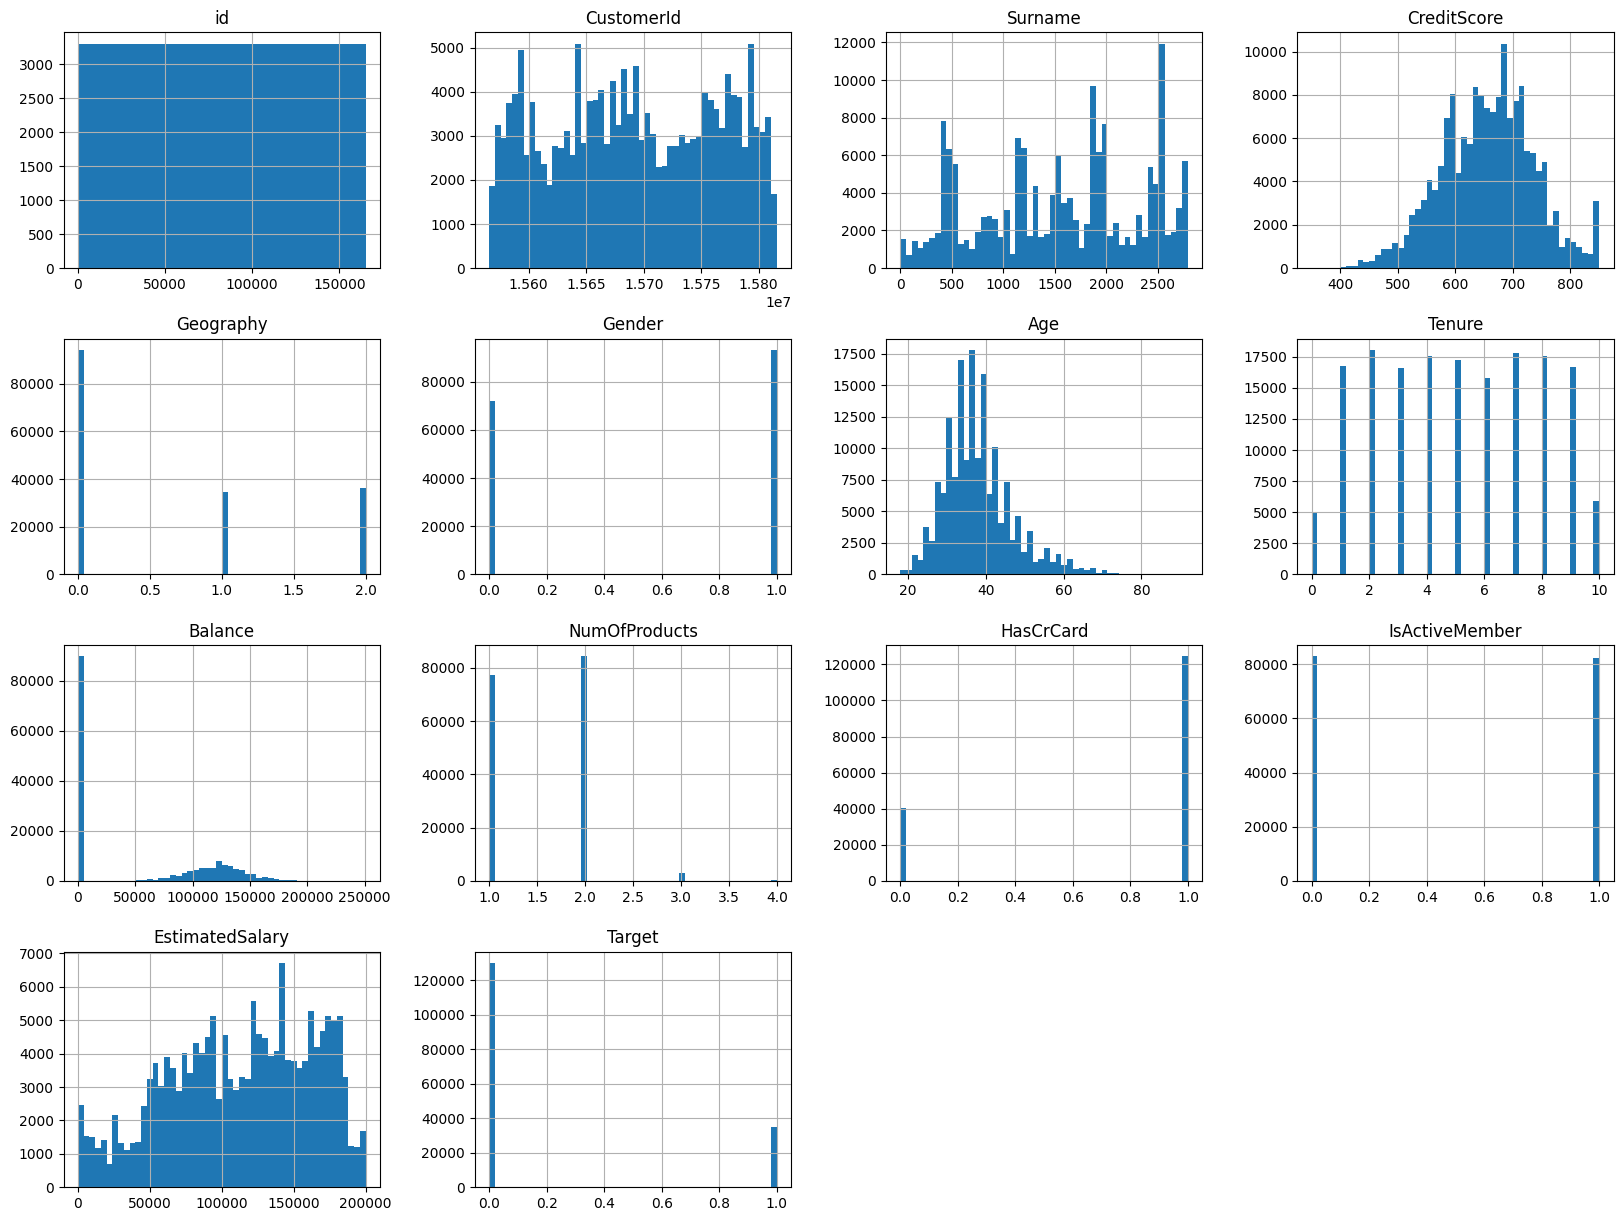

In [14]:
train_data.hist(bins=50, figsize = [20,15])
plt.show()

Let's make sure that we have a balanced dataset, so our predictions will not be skewed.

Target
0    130113
1     34921
Name: count, dtype: int64

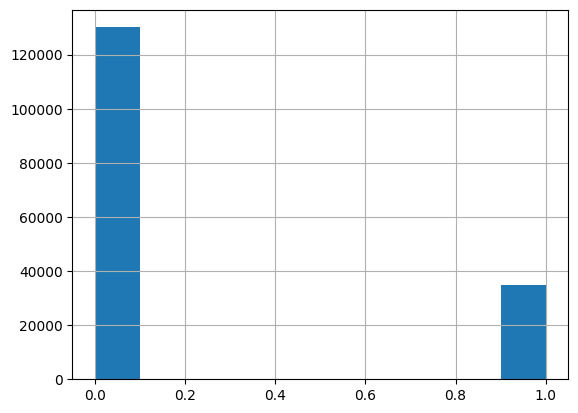

In [15]:
train_data['Target'].hist()
train_data['Target'].value_counts()

There seems to be an excess of 0 values, which means our dataset is not balanced. To solve this problem, we can implement undersampling of the majority value, 0.

Target
0    130113
1    130113
Name: count, dtype: int64

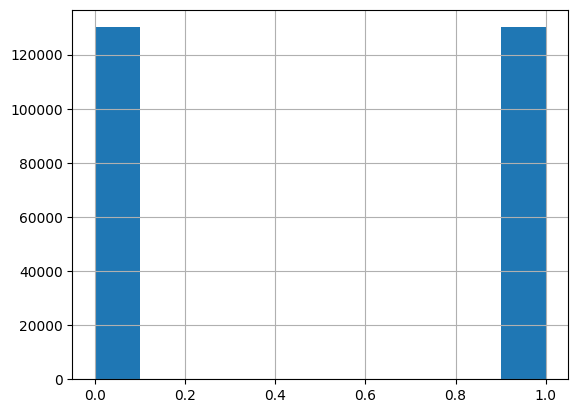

In [16]:
X = train_data.drop('Target', axis=1)  # Features
y = train_data['Target']  # Target variable

# Create a RandomOverSampler object
ros = RandomOverSampler(random_state=42)

# Fit and apply the random over-sampling
X_resampled, y_resampled = ros.fit_resample(X, y)

# Create a new dataframe with the resampled data
resampled_data = pd.concat([pd.DataFrame(X_resampled, columns=X.columns), pd.Series(y_resampled, name='Target')], axis=1)

# Check the distribution of the target variable after over-sampling
resampled_data['Target'].hist()
resampled_data['Target'].value_counts()

Now that our target value is distributed evenly between 0s and 1s, we can proceed.

In [17]:
resampled_data_corr = resampled_data.corr()
resampled_data_corr["Target"].sort_values(ascending = False)

Target             1.000000
Age                0.396172
Balance            0.159417
Geography          0.066194
EstimatedSalary    0.023731
id                 0.002428
CustomerId        -0.010899
Tenure            -0.024429
HasCrCard         -0.025477
Surname           -0.035203
CreditScore       -0.035498
Gender            -0.176621
NumOfProducts     -0.239055
IsActiveMember    -0.260164
Name: Target, dtype: float64

It seems like the variables with the most correlation to our target are "Age", "IsActiveMember", and "NumOfProducts".

Now, we should save the target category in a separate array and drop the category from our dataframe.

In [18]:
target_name = 'Target'
resampled_data_target = resampled_data[target_name]
resampled_data = resampled_data.drop("Target", axis=1)# check HW1 for usage of dropping a column
resampled_data.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,0,15674932,1924,668,0,1,33.0,3,0.00,2,1.0,0.0,181449.97
1,1,15749177,1925,627,0,1,33.0,1,0.00,2,1.0,1.0,49503.50
2,2,15694510,1178,678,0,1,40.0,10,0.00,2,1.0,0.0,184866.69
3,3,15741417,1299,581,0,1,34.0,2,148882.54,1,1.0,1.0,84560.88
4,4,15766172,467,716,2,1,33.0,5,0.00,2,1.0,1.0,15068.83


In [19]:
resampled_data_target.head()

0    0
1    0
2    0
3    0
4    0
Name: Target, dtype: int64

Now, we can use the train_test_split method to create our unprocessed training data by dividing the dataframe into testing and training cohorts.

In [20]:
# training data consists of 80% of total dataframe
train_raw, test_raw, target_raw, target_raw_test = train_test_split(resampled_data, resampled_data_target, test_size = 0.2, random_state = 30)

Sanity check (output resulting training and testing samples)

In [21]:
print(train_raw.shape, target_raw.shape)
print(test_raw.shape, target_raw_test.shape)

(208180, 13) (208180,)
(52046, 13) (52046,)


Let's try using KNN (K-Nearest-Neighbors) first, and see how accurate that is.

In [22]:
# k_values = [1,2,3,5,7,9,10,20,200]
#     # uncomment to test the k-values to find the one yielding highest accuracy

# for k in k_values:
#   neigh = KNeighborsClassifier(n_neighbors=k)
#   neigh.fit(train_raw, target_raw)
#   raw_predicted = neigh.predict(test_raw)
#   print('Accuracy for k = ', k, ':', metrics.accuracy_score(target_raw_test,raw_predicted))

In [23]:
from sklearn.neighbors import KNeighborsClassifier
neigh = KNeighborsClassifier(n_neighbors=1)
neigh.fit(train_raw, target_raw)
raw_predicted = neigh.predict(test_raw)

In [24]:
print('Accuracy:', metrics.accuracy_score(target_raw_test,raw_predicted))

Accuracy: 0.8650808899819391


After testing out different k-values, the value 1 seemed to produce the highest accuracy. 86.51% isn't too bad.

Precision:   0.802650
Recall:      0.967587
F1 Score:    0.877435
Confusion Matrix: 



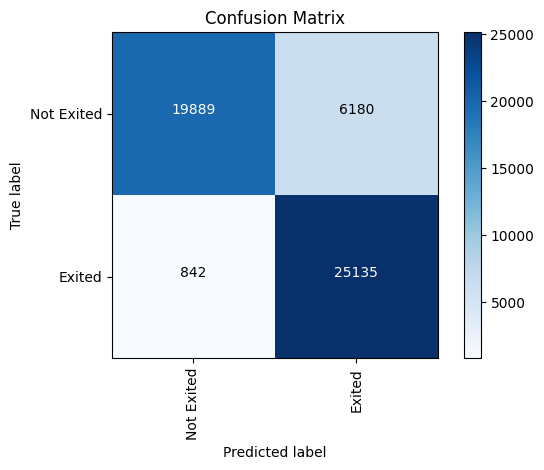

In [25]:
print("%-12s %f" % ('Precision:', metrics.precision_score(target_raw_test, raw_predicted,labels=None, pos_label=1, average='binary', sample_weight=None)))
print("%-12s %f" % ('Recall:', metrics.recall_score(target_raw_test, raw_predicted,labels=None, pos_label=1, average='binary', sample_weight=None)))
print("%-12s %f" % ('F1 Score:', metrics.f1_score(target_raw_test, raw_predicted,labels=None, pos_label=1, average='binary', sample_weight=None)))

print("Confusion Matrix: \n")
draw_confusion_matrix(target_raw_test, raw_predicted, ['Not Exited', 'Exited'])

Now, let's try using a logistic regression model instead!

In [26]:
log_reg = LogisticRegression(C = 0.5)
log_reg.fit(train_raw, target_raw)
log_predicted = log_reg.predict(test_raw)
log_score = log_reg.predict_proba(test_raw)[:,1]

In [27]:
# report accuracy, precision, Recall, and F1 score
print('Accuracy:', metrics.accuracy_score(target_raw_test,log_predicted))
print('Precision:', metrics.precision_score(target_raw_test, log_predicted,labels=None, pos_label=1, average='binary', sample_weight=None))
print('Recall:', metrics.recall_score(target_raw_test, log_predicted,labels=None, pos_label=1, average='binary', sample_weight=None))
print('F1 Score:', metrics.f1_score(target_raw_test, log_predicted,labels=None, pos_label=1, average='binary', sample_weight=None))

Accuracy: 0.5790454597855743
Precision: 0.5783332049603327
Recall: 0.5780883088886323
F1 Score: 0.5782107309935891


Ew, the accuracy is so low. I tried adjusting the lambda value but it didn't improve the accuracy. Here's a graph of the ROC curve.

Logistic Model Performance Results:

AUC of ROC:  0.585214175415827


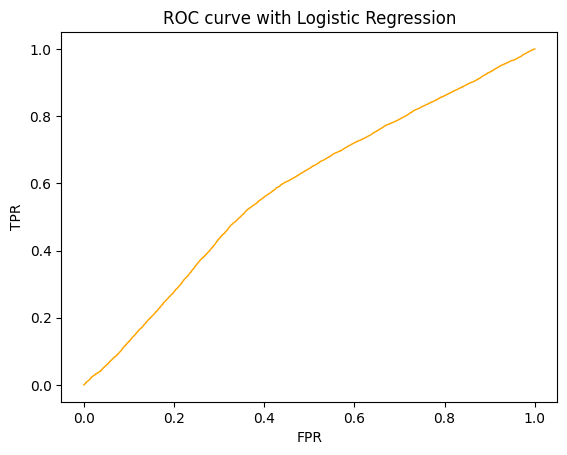

In [28]:
fpr_log_reg, tpr_log_reg, thresholds = metrics.roc_curve(target_raw_test,log_score)
print("Logistic Model Performance Results:\n")
pyplot.figure(1)
pyplot.plot(fpr_log_reg, tpr_log_reg, color='orange', lw=1)
pyplot.title("ROC curve with Logistic Regression")
pyplot.xlabel('FPR')
pyplot.ylabel('TPR')



# report auc
# use metrics.auc(fpr, tpr)
aucroc = metrics.auc(fpr_log_reg, tpr_log_reg)
print('AUC of ROC: ', aucroc)

Confusion Matrix: 



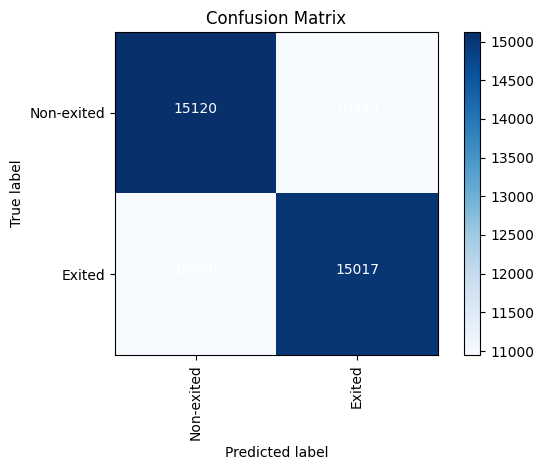

In [29]:
print("Confusion Matrix: \n")
draw_confusion_matrix(target_raw_test, log_predicted, ['Non-exited', 'Exited'])

What happened to the upper-right and lower-left squares? Whatever, this model failed anyway. Let's just move on. What if I implemented no penalty into the logistic regression model instead?

In [30]:
log_reg_nopenalty = LogisticRegression(penalty = None)
log_reg_nopenalty.fit(train_raw, target_raw)
log_predicted_nopenalty = log_reg_nopenalty.predict(test_raw)
log_score_nopenalty = log_reg_nopenalty.predict_proba(test_raw)[:,1]

In [31]:
print('Accuracy:', metrics.accuracy_score(target_raw_test,log_predicted_nopenalty))

Accuracy: 0.5790454597855743


Anyway, let's move on to a different method. Let's see if random forest produces better results!

In [32]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector, make_column_transformer
from sklearn.pipeline import Pipeline


num_pipeline = make_pipeline(SimpleImputer(strategy = "median"),
                            StandardScaler())
cat_pipeline = make_pipeline(SimpleImputer(strategy = "most_frequent"),
                            OneHotEncoder(handle_unknown = "ignore"))

preprocessing = make_column_transformer(
                            (num_pipeline, make_column_selector(dtype_include = np.number)),
                            (cat_pipeline, make_column_selector(dtype_include = object)),
)

# X_train, X_valid, y_train, y_valid = train_test_split(train, train_labels, test_size=0.2, random_state=42)

In [33]:
forest_model = RandomForestClassifier(random_state = 42)
forest_pipeline = Pipeline(steps=[('preprocessor', preprocessing),
                               ('model', forest_model)])

forest_pipeline.fit(train_raw, target_raw)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7bda23f6d600>),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7bda2c2d5cc0>)])),
                ('model', RandomForestClassifier(random_state=42))])

In [34]:
valid_probs = forest_pipeline.predict_proba(test_raw)

valid_transported_probs = valid_probs[:, 1]
auc_score = roc_auc_score(target_raw_test, valid_transported_probs)
auc_score

0.992039923991517

Not bad at all, 99.2% accuracy rate. Great!

That's it so far, thanks for checking out my notebook! Please let me know in the comments if you have any suggestions for me to improve my code :) thanks!